<a href="https://colab.research.google.com/github/nikhilRajput-prog/Deep-Learning-Lab-File/blob/main/deep_learning_exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Experiment->9



In [1]:
!pip install wandb -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]


In [3]:
Z_DIM = 100
EPOCHS = 10
LR = 0.0002

MODEL_TYPE = "DCGAN"   # "GAN" or "DCGAN"
LOSS_TYPE = "BCE"      # "BCE", "LSGAN", "WGAN"
OPTIMIZER = "Adam"     # "Adam", "RMSprop", "SGD"

USE_WANDB = False

In [4]:
class Generator_GAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator_GAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() if LOSS_TYPE != "WGAN" else nn.Identity()
        )

    def forward(self, x):
        return self.net(x)

In [5]:
class Generator_DCGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 128, 7, 1, 0),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z.view(-1, Z_DIM, 1, 1))


class Discriminator_DCGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid() if LOSS_TYPE != "WGAN" else nn.Identity()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
if MODEL_TYPE == "GAN":
    G = Generator_GAN().to(device)
    D = Discriminator_GAN().to(device)
else:
    G = Generator_DCGAN().to(device)
    D = Discriminator_DCGAN().to(device)

In [7]:
bce = nn.BCELoss()
mse = nn.MSELoss()

def d_loss_fn(real, fake):
    if LOSS_TYPE == "BCE":
        return bce(real, torch.ones_like(real)) + bce(fake, torch.zeros_like(fake))
    elif LOSS_TYPE == "LSGAN":
        return mse(real, torch.ones_like(real)) + mse(fake, torch.zeros_like(fake))
    else:  # WGAN
        return -(torch.mean(real) - torch.mean(fake))


def g_loss_fn(fake):
    if LOSS_TYPE == "BCE":
        return bce(fake, torch.ones_like(fake))
    elif LOSS_TYPE == "LSGAN":
        return mse(fake, torch.ones_like(fake))
    else:  # WGAN
        return -torch.mean(fake)

In [8]:
def get_optimizer(params):
    if OPTIMIZER == "Adam":
        return optim.Adam(params, lr=LR, betas=(0.5, 0.999))
    elif OPTIMIZER == "RMSprop":
        return optim.RMSprop(params, lr=LR)
    else:
        return optim.SGD(params, lr=LR)

opt_G = get_optimizer(G.parameters())
opt_D = get_optimizer(D.parameters())

In [9]:
def get_optimizer(params):
    if OPTIMIZER == "Adam":
        return optim.Adam(params, lr=LR, betas=(0.5, 0.999))
    elif OPTIMIZER == "RMSprop":
        return optim.RMSprop(params, lr=LR)
    else:
        return optim.SGD(params, lr=LR)

opt_G = get_optimizer(G.parameters())
opt_D = get_optimizer(D.parameters())

In [10]:
def show_images(images, epoch):
    images = images[:16].detach().cpu()
    grid = torchvision.utils.make_grid(images, nrow=4, normalize=True)
    plt.figure(figsize=(5,5))
    plt.title(f"Epoch {epoch}")
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.axis('off')
    plt.show()

Epoch 1/10 | D Loss: 0.6212 | G Loss: 1.7511


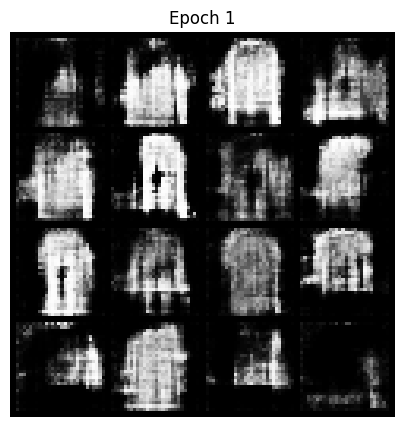

Epoch 2/10 | D Loss: 0.8808 | G Loss: 1.9410


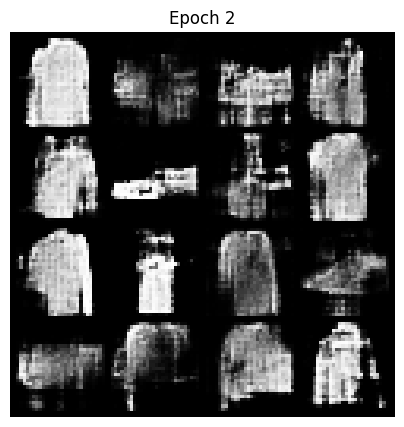

Epoch 3/10 | D Loss: 0.9631 | G Loss: 1.6995


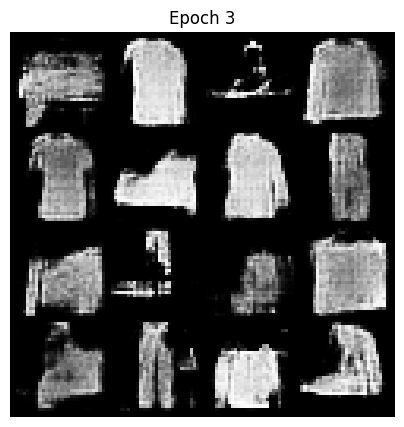

Epoch 4/10 | D Loss: 1.1005 | G Loss: 1.0053


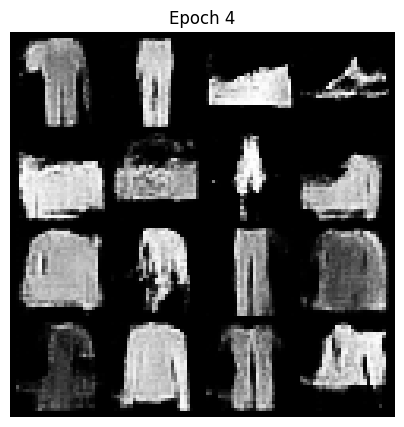

Epoch 5/10 | D Loss: 0.9774 | G Loss: 0.7374


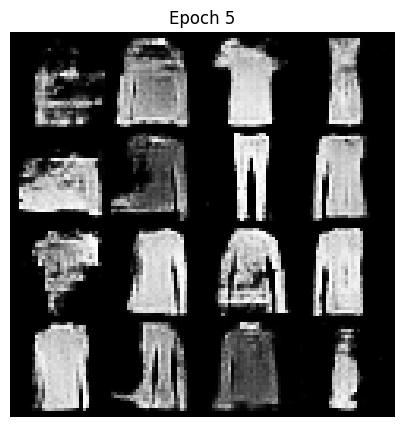

Epoch 6/10 | D Loss: 0.9608 | G Loss: 1.0085


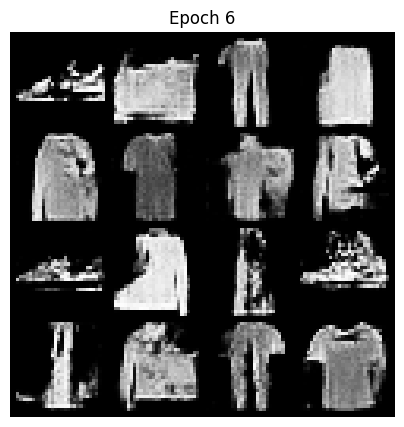

Epoch 7/10 | D Loss: 0.9083 | G Loss: 1.4557


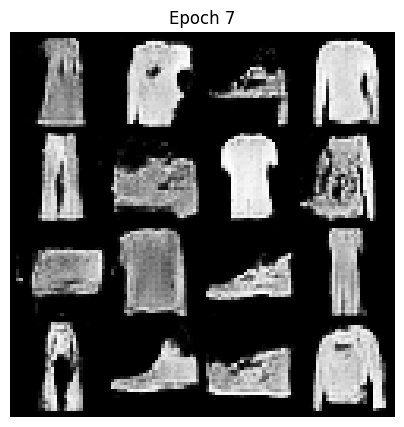

Epoch 8/10 | D Loss: 1.1374 | G Loss: 0.6794


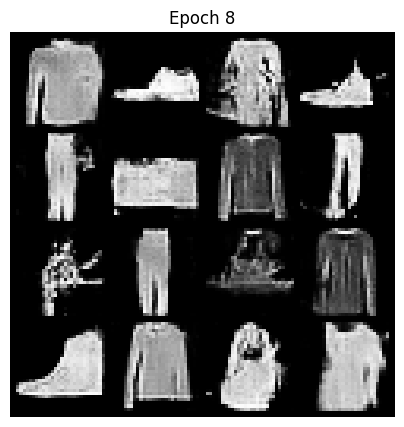

Epoch 9/10 | D Loss: 1.0891 | G Loss: 1.1296


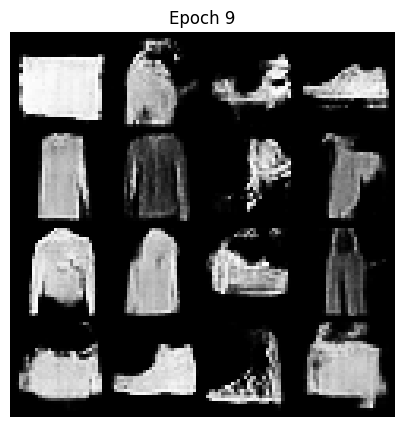

Epoch 10/10 | D Loss: 1.3169 | G Loss: 2.3817


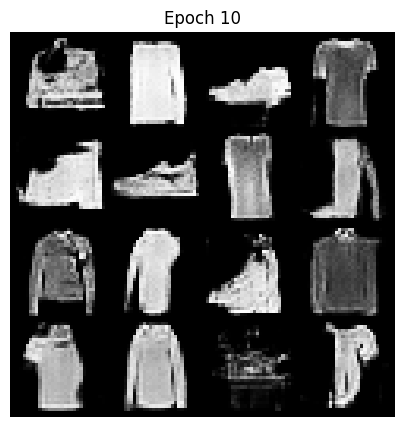

In [11]:
for epoch in range(EPOCHS):
    for real, _ in loader:
        real = real.to(device)
        batch_size = real.size(0)

        z = torch.randn(batch_size, Z_DIM).to(device)

        # ---- Train Discriminator ----
        fake = G(z).detach()
        d_real = D(real)
        d_fake = D(fake)

        loss_D = d_loss_fn(d_real, d_fake)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        if LOSS_TYPE == "WGAN":
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # ---- Train Generator ----
        z = torch.randn(batch_size, Z_DIM).to(device)
        fake = G(z)
        d_fake = D(fake)

        loss_G = g_loss_fn(d_fake)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    show_images(G(torch.randn(16, Z_DIM).to(device)), epoch+1)

In [12]:
torch.save(G.state_dict(), "generator.pth")
print("Model saved!")

Model saved!


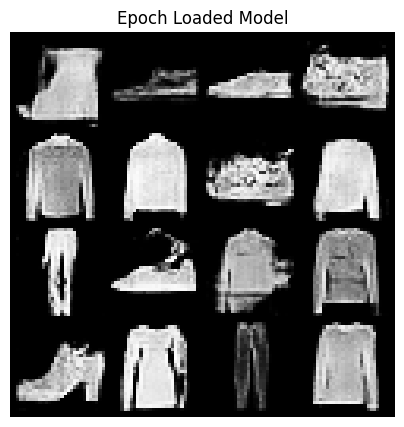

In [13]:
# Load model
G_loaded = type(G)().to(device)
G_loaded.load_state_dict(torch.load("generator.pth", map_location=device))
G_loaded.eval()

# Generate images
z = torch.randn(16, Z_DIM).to(device)
fake_images = G_loaded(z)

show_images(fake_images, "Loaded Model")

In [14]:
G_losses = []
D_losses = []

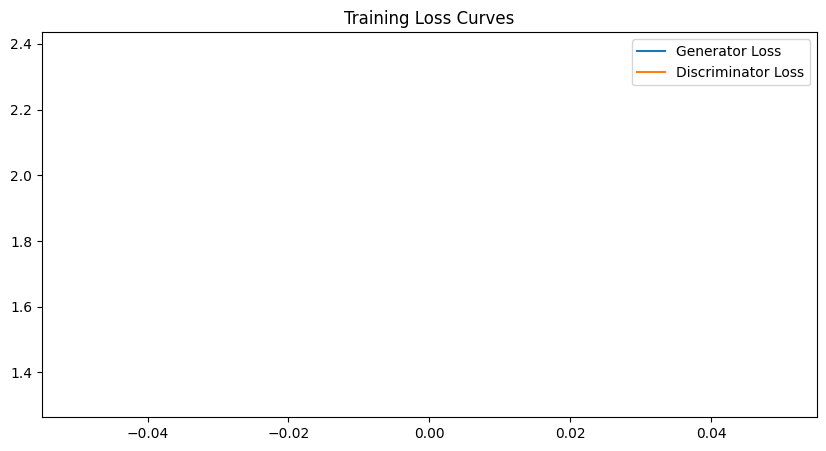

In [15]:
G_losses.append(loss_G.item())
D_losses.append(loss_D.item())
plt.figure(figsize=(10,5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.legend()
plt.title("Training Loss Curves")
plt.show()


Running: GAN, BCE, Adam


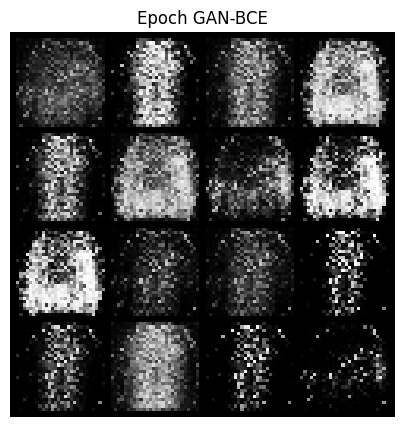


Running: GAN, LSGAN, RMSprop


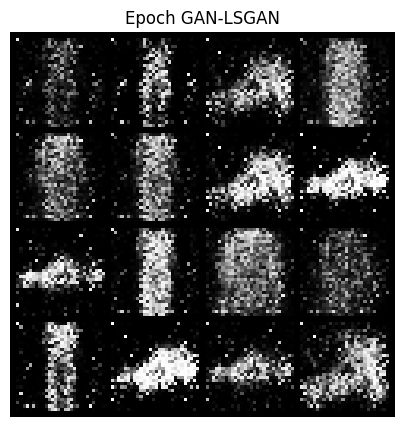


Running: DCGAN, BCE, Adam


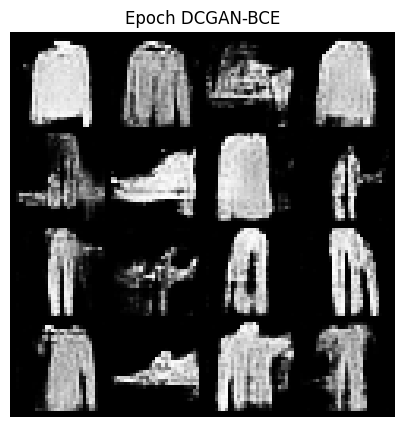


Running: DCGAN, WGAN, RMSprop


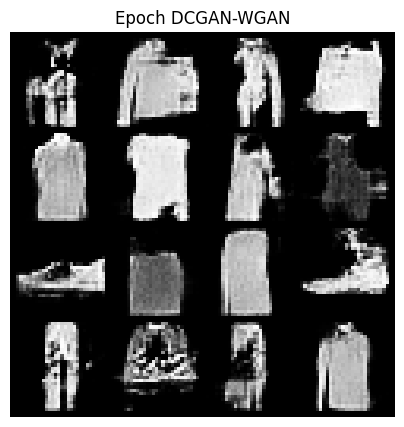

In [16]:
experiments = [
    ("GAN", "BCE", "Adam"),
    ("GAN", "LSGAN", "RMSprop"),
    ("DCGAN", "BCE", "Adam"),
    ("DCGAN", "WGAN", "RMSprop"),
]

results = []

for model_type, loss_type, optimizer_type in experiments:
    print(f"\nRunning: {model_type}, {loss_type}, {optimizer_type}")

    MODEL_TYPE = model_type
    LOSS_TYPE = loss_type
    OPTIMIZER = optimizer_type

    # Reinitialize models
    if MODEL_TYPE == "GAN":
        G = Generator_GAN().to(device)
        D = Discriminator_GAN().to(device)
    else:
        G = Generator_DCGAN().to(device)
        D = Discriminator_DCGAN().to(device)

    opt_G = get_optimizer(G.parameters())
    opt_D = get_optimizer(D.parameters())

    for epoch in range(3):  # keep small for comparison
        for real, _ in loader:
            real = real.to(device)
            batch_size = real.size(0)

            z = torch.randn(batch_size, Z_DIM).to(device)

            # Train D
            fake = G(z).detach()
            d_real = D(real)
            d_fake = D(fake)

            loss_D = d_loss_fn(d_real, d_fake)

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Train G
            z = torch.randn(batch_size, Z_DIM).to(device)
            fake = G(z)
            d_fake = D(fake)

            loss_G = g_loss_fn(d_fake)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

    results.append((model_type, loss_type, optimizer_type, loss_G.item(), loss_D.item()))

    show_images(G(torch.randn(16, Z_DIM).to(device)), f"{model_type}-{loss_type}")

In [17]:
for r in results:
    print(f"Model: {r[0]}, Loss: {r[1]}, Opt: {r[2]} | G Loss: {r[3]:.4f}, D Loss: {r[4]:.4f}")

Model: GAN, Loss: BCE, Opt: Adam | G Loss: 2.4207, D Loss: 0.3657
Model: GAN, Loss: LSGAN, Opt: RMSprop | G Loss: 0.8519, D Loss: 0.3485
Model: DCGAN, Loss: BCE, Opt: Adam | G Loss: 1.0944, D Loss: 0.9677
Model: DCGAN, Loss: WGAN, Opt: RMSprop | G Loss: 103.3718, D Loss: -29.8093


In [18]:
if USE_WANDB:
    wandb.init(project="GAN-Experiment")

    wandb.log({
        "Generator Loss": loss_G.item(),
        "Discriminator Loss": loss_D.item()
    })

In [19]:
import os

os.makedirs("outputs", exist_ok=True)

for i in range(10):
    z = torch.randn(1, Z_DIM).to(device)
    img = G(z).detach().cpu()

    torchvision.utils.save_image(img, f"outputs/sample_{i}.png", normalize=True)

print("Images saved in outputs/")

Images saved in outputs/
